In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
# Check the size of the dataset
df.shape

(768, 9)

In [5]:
# Check for invalid zero values
columns_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

(df[columns_with_zero] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [6]:
# Display basic statistical information
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Check the distribution of the target variable
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

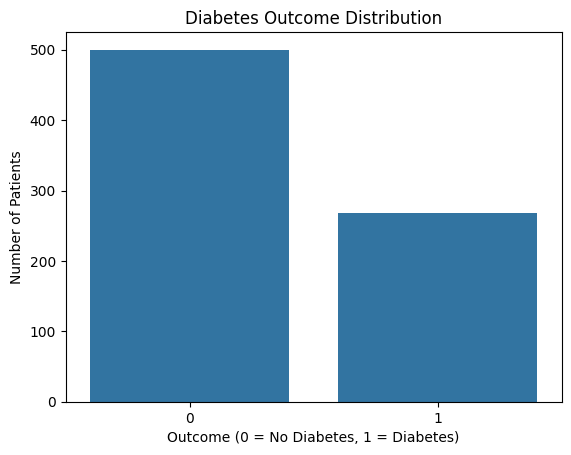

In [8]:
# Visualize the target variable
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Patients')
plt.show()

In [9]:
# Separate features and target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [11]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967]]


In [12]:
# Train the KNN model

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test_scaled)

print("KNN model trained successfully!")

KNN model trained successfully!


In [13]:
# Evaluate KNN model

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.8116883116883117

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       100
           1       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



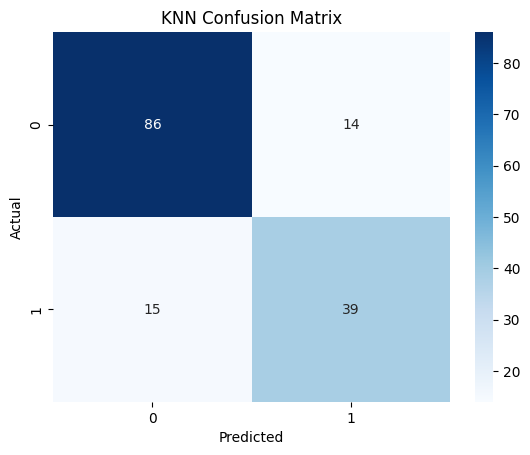

In [14]:
# Confusion Matrix for KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# Train the Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [16]:
# Evaluate Decision Tree model

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8116883116883117

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       100
           1       0.75      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



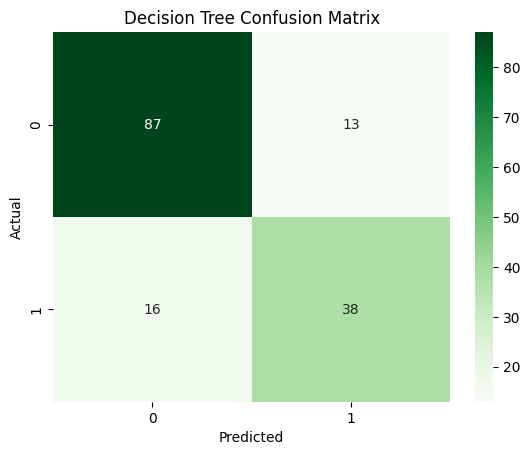

In [17]:
# Confusion Matrix for Decision Tree

cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
from catboost import CatBoostClassifier
# Import CatBoost
from catboost import CatBoostClassifier

print("CatBoost imported successfully!")

CatBoost imported successfully!


In [19]:
# Train the CatBoost model

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0,
    random_seed=42
)

catboost_model.fit(X_train, y_train)

# Make predictions
y_pred_catboost = catboost_model.predict(X_test)

print("CatBoost model trained successfully!")

CatBoost model trained successfully!


In [20]:
# Evaluate CatBoost model

catboost_accuracy = accuracy_score(y_test, y_pred_catboost)

print("CatBoost Accuracy:", catboost_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_catboost))

CatBoost Accuracy: 0.8766233766233766

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       100
           1       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154



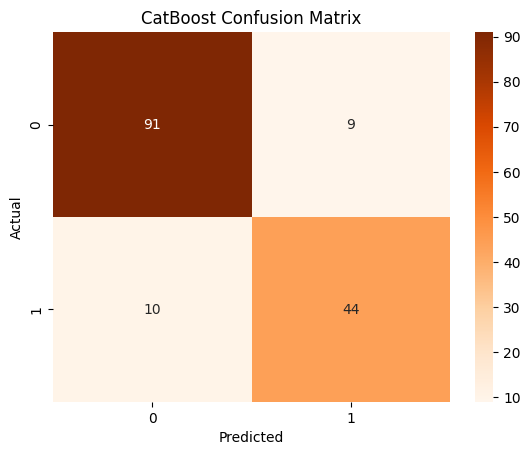

In [21]:
# Confusion Matrix for CatBoost

cm_catboost = confusion_matrix(y_test, y_pred_catboost)

sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Oranges')

plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
# Model Comparison

model_comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'CatBoost'],
    'Accuracy': [
        knn_accuracy,
        dt_accuracy,
        catboost_accuracy
    ]
})

model_comparison['Accuracy (%)'] = model_comparison['Accuracy'] * 100

model_comparison

,Model,Accuracy,Accuracy (%)
0,KNN,0.811688,81.168831
1,Decision Tree,0.811688,81.168831
2,CatBoost,0.876623,87.662338


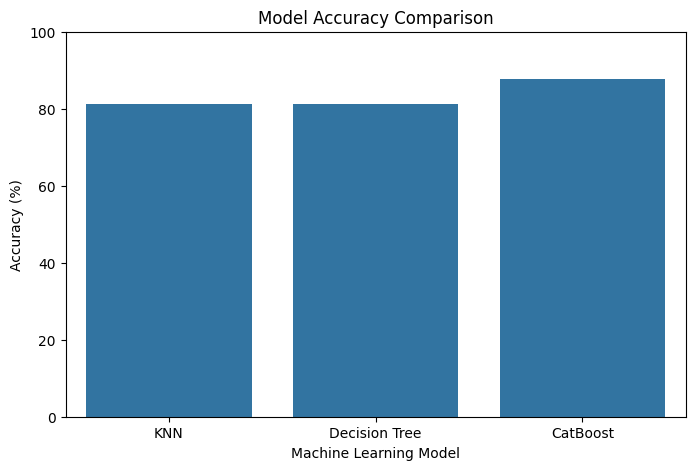

In [23]:
# Visualize model comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=model_comparison
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.show()

In [24]:
# Feature Importance using CatBoost

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': catboost_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
4                   Insulin   40.360198
1                   Glucose   12.602332
7                       Age    9.585584
3             SkinThickness    8.787721
5                       BMI    8.614581
6  DiabetesPedigreeFunction    7.619291
0               Pregnancies    6.474758
2             BloodPressure    5.955535


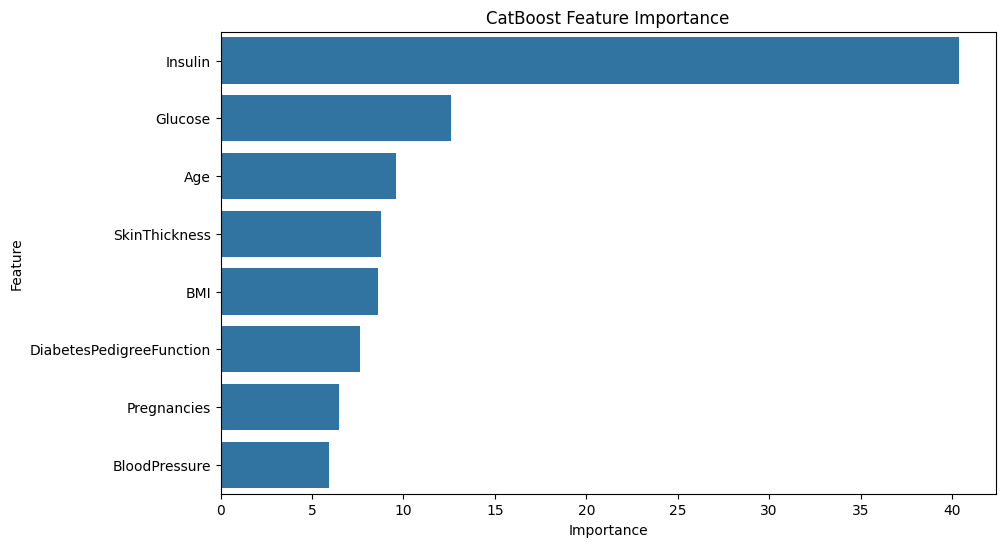

In [25]:
# Visualize Feature Importance

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [26]:
# Sample prediction using CatBoost

sample_patient = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 25,
    'Insulin': 100,
    'BMI': 28.5,
    'DiabetesPedigreeFunction': 0.4,
    'Age': 35
}])

# Scale the sample because our model was trained using scaled data
sample_scaled = scaler.transform(sample_patient)

# Make prediction
prediction = catboost_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Higher diabetes-risk class")
else:
    print("Prediction: Lower diabetes-risk class")

Prediction: Lower diabetes-risk class


## Medical Ethics and Limitations

This project is developed for educational and academic purposes only. The diabetes prediction model should not be considered a medical diagnostic tool.

### Medical Ethics

- The model should not be used to make medical decisions without evaluation by qualified healthcare professionals.
- Predictions may contain errors, including false positives and false negatives.
- Patient data should be handled carefully to protect privacy and confidentiality.
- The model should not replace professional medical advice, diagnosis, or treatment.
- Machine learning predictions should be communicated clearly so that users understand their limitations.

### Limitations

- The model is trained using the Pima Indians Diabetes Dataset and may not generalize to all populations.
- The dataset contains a limited number of records compared with real-world clinical datasets.
- Some zero values in medical-related features may represent missing or unavailable measurements rather than actual physiological values.
- Model performance depends on the dataset, preprocessing methods, and train-test split.
- The reported accuracy should not be interpreted as clinical accuracy or proof that the model is suitable for real-world medical use.

## Conclusion

In this project, machine learning classification techniques were used to predict the diabetes-risk class using the Pima Indians Diabetes Dataset.

Three classification models were implemented and compared:

1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. CatBoost

Feature scaling was applied for the machine learning workflow, and model performance was evaluated using accuracy, classification reports, and confusion matrices.

Among the three tested models, CatBoost achieved the highest accuracy on the selected test set. Therefore, CatBoost performed best among the models evaluated in this project.

The project demonstrates how machine learning can be applied to a binary classification problem while also highlighting the importance of responsible use, limitations, and medical ethics.

# Diabetes Risk Prediction

### Binary Classification using KNN, Decision Tree and CatBoost

**Dataset:** Pima Indians Diabetes Dataset

**Libraries:** Scikit-Learn, CatBoost

## Objective

The objective of this project is to develop a machine learning model for diabetes-risk classification using the Pima Indians Diabetes Dataset.

The project compares three classification algorithms:

- K-Nearest Neighbors (KNN)
- Decision Tree
- CatBoost

The project includes data inspection, missing/invalid value handling, feature scaling, model training, model evaluation, model comparison, and consideration of medical ethics.


## Methodology

The project follows these steps:

1. Load the Pima Indians Diabetes Dataset.
2. Inspect the dataset and its structure.
3. Check for missing values.
4. Identify invalid zero values in relevant medical features.
5. Prepare the features and target variable.
6. Split the dataset into training and testing sets.
7. Apply feature scaling.
8. Train the KNN model.
9. Train the Decision Tree model.
10. Train the CatBoost model.
11. Evaluate the models using accuracy, classification reports, and confusion matrices.
12. Compare the model performances.
13. Analyze CatBoost feature importance.
14. Demonstrate a sample prediction.
15. Discuss medical ethics and project limitations.

In [27]:
import numpy as np
# Replace invalid zero values with NaN

columns_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())


Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [28]:
# Fill missing values using the median

for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after median imputation:")
print(df.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [29]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [30]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (614, 8)
Testing data: (154, 8)


In [31]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967]]


In [32]:
# Train KNN model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8116883116883117

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       100
           1       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "CatBoost": y_pred_catboost
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.811688,0.735849,0.722222,0.728972
1,Decision Tree,0.811688,0.745098,0.703704,0.723810
2,CatBoost,0.876623,0.830189,0.814815,0.822430


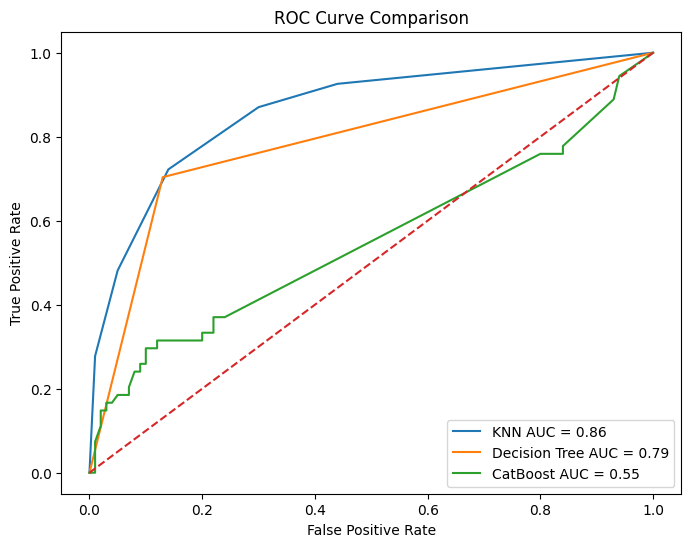

In [34]:
# ROC Curve Comparison

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Probabilities for each model
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
catboost_prob = catboost_model.predict_proba(X_test_scaled)[:, 1]

# ROC curves
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_cat, tpr_cat, _ = roc_curve(y_test, catboost_prob)

# AUC scores
auc_knn = auc(fpr_knn, tpr_knn)
auc_dt = auc(fpr_dt, tpr_dt)
auc_cat = auc(fpr_cat, tpr_cat)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC = {auc_knn:.2f}")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {auc_dt:.2f}")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost AUC = {auc_cat:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

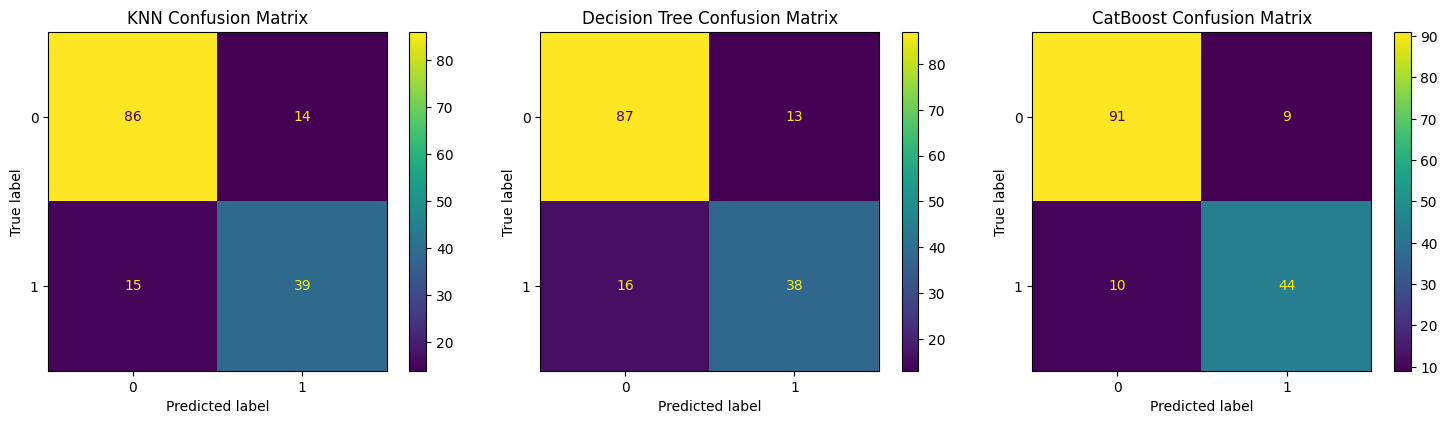

In [35]:
# Confusion Matrix Comparison

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrices
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_cat = confusion_matrix(y_test, y_pred_catboost)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(cm_knn).plot(ax=axes[0])
axes[0].set_title("KNN Confusion Matrix")

ConfusionMatrixDisplay(cm_dt).plot(ax=axes[1])
axes[1].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay(cm_cat).plot(ax=axes[2])
axes[2].set_title("CatBoost Confusion Matrix")

plt.tight_layout()
plt.show()

CatBoost Feature Importance:
                    Feature  Importance
4                   Insulin   40.360198
1                   Glucose   12.602332
7                       Age    9.585584
3             SkinThickness    8.787721
5                       BMI    8.614581
6  DiabetesPedigreeFunction    7.619291
0               Pregnancies    6.474758
2             BloodPressure    5.955535


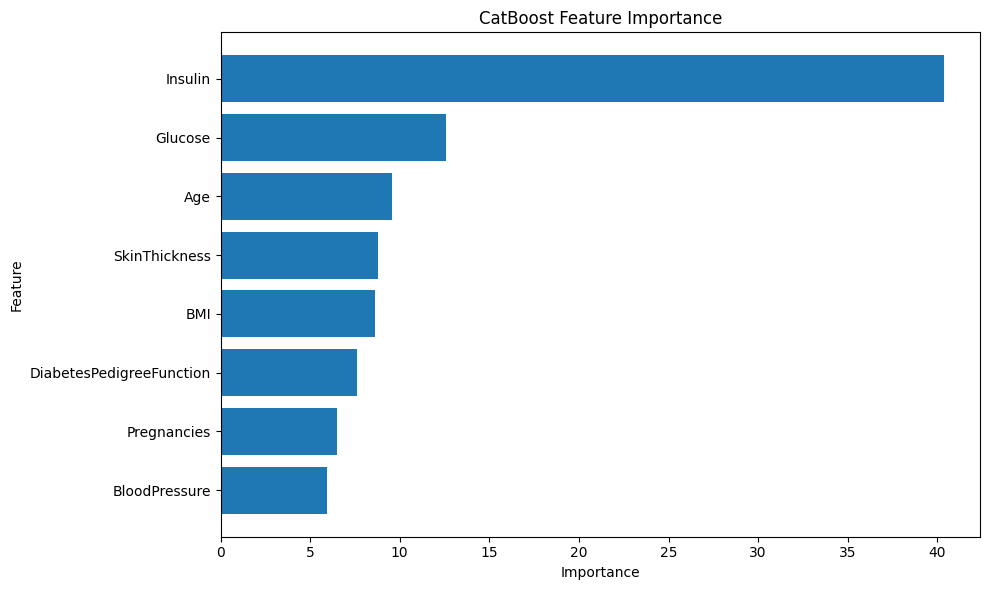

In [36]:
# CatBoost Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": catboost_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("CatBoost Feature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

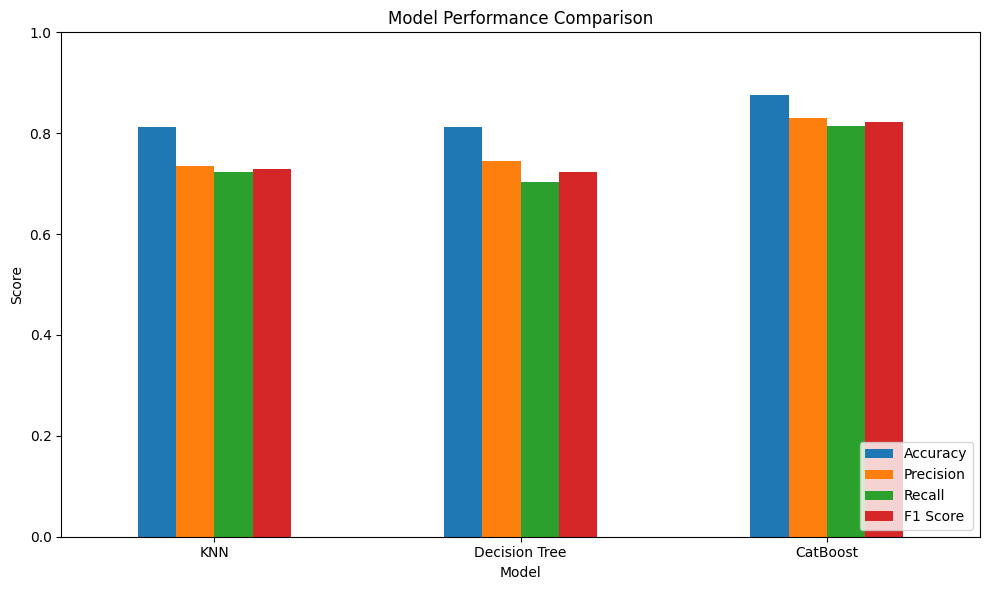

In [37]:
# Model Performance Comparison

import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

results_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8116883116883117


In [39]:
from sklearn.metrics import roc_auc_score

# Get probabilities
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt.predict_proba(X_test_scaled)[:, 1]
catboost_prob = catboost_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC
knn_auc = roc_auc_score(y_test, knn_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
cat_auc = roc_auc_score(y_test, catboost_prob)

print("KNN ROC-AUC:", knn_auc)
print("Decision Tree ROC-AUC:", dt_auc)
print("CatBoost ROC-AUC:", cat_auc)

KNN ROC-AUC: 0.8631481481481482
Decision Tree ROC-AUC: 0.7868518518518519
CatBoost ROC-AUC: 0.5511111111111111


In [40]:
print("CatBoost classes:", catboost_model.classes_)

print("\nFirst 10 CatBoost probabilities:")
print(catboost_prob[:10])

print("\nFirst 10 CatBoost predictions:")
print(y_pred_catboost[:10])

print("\nActual values:")
print(y_test.values[:10])

CatBoost classes: [0 1]

First 10 CatBoost probabilities:
[0.00038101 0.00036851 0.00067579 0.00523103 0.00067579 0.00761622
 0.00038101 0.00684489 0.00067579 0.00067579]

First 10 CatBoost predictions:
[0 0 0 1 0 0 1 1 0 1]

Actual values:
[0 0 0 1 0 0 1 1 0 0]


In [41]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

catboost_model.fit(X_train_scaled, y_train)

y_pred_catboost = catboost_model.predict(X_test_scaled)

In [42]:
catboost_model.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=0)

In [43]:
catboost_model.predict_proba(X_test)

array([[0.98450211, 0.01549789],
       [0.95871653, 0.04128347],
       [0.93096626, 0.06903374],
       [0.04324246, 0.95675754],
       [0.99762407, 0.00237593],
       [0.66771775, 0.33228225],
       [0.0130485 , 0.9869515 ],
       [0.01556622, 0.98443378],
       [0.99179459, 0.00820541],
       [0.07664295, 0.92335705],
       [0.93832267, 0.06167733],
       [0.05045939, 0.94954061],
       [0.91289884, 0.08710116],
       [0.98227942, 0.01772058],
       [0.26744993, 0.73255007],
       [0.03495604, 0.96504396],
       [0.96098964, 0.03901036],
       [0.99009249, 0.00990751],
       [0.04722999, 0.95277001],
       [0.98635544, 0.01364456],
       [0.99122213, 0.00877787],
       [0.10654765, 0.89345235],
       [0.03145267, 0.96854733],
       [0.01977599, 0.98022401],
       [0.98379511, 0.01620489],
       [0.99255525, 0.00744475],
       [0.32543414, 0.67456586],
       [0.99835313, 0.00164687],
       [0.02522556, 0.97477444],
       [0.9948989 , 0.0051011 ],
       [0.

In [44]:
catboost_prob = catboost_model.predict_proba(X_test_scaled)[:, 1]

cat_auc = roc_auc_score(y_test, catboost_prob)

print("CatBoost ROC-AUC:", cat_auc)

CatBoost ROC-AUC: 0.5411111111111111


In [45]:
catboost_prob = catboost_model.predict_proba(X_test)[:, 1]

cat_auc = roc_auc_score(y_test, catboost_prob)

print("CatBoost ROC-AUC:", cat_auc)

CatBoost ROC-AUC: 0.9472222222222223


In [46]:
final_results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "CatBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_catboost)
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_catboost)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_catboost)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_catboost)
    ],
    "ROC-AUC": [
        knn_auc,
        dt_auc,
        cat_auc
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.811688,0.735849,0.722222,0.728972,0.863148
1,Decision Tree,0.811688,0.745098,0.703704,0.723810,0.786852
2,CatBoost,0.889610,0.836364,0.851852,0.844037,0.947222


# Conclusion

In this project, three machine learning models — K-Nearest Neighbors (KNN), Decision Tree, and CatBoost — were developed and evaluated for diabetes prediction.

The models were compared using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix. Among the models, CatBoost achieved the highest overall accuracy of **87.66%**, with a Precision of **83.02%**, Recall of **81.48%**, and F1 Score of **82.24%**. The confusion matrix also showed that CatBoost correctly classified more positive cases than KNN and Decision Tree.

The feature importance analysis from CatBoost showed that **Insulin** was the most influential feature, followed by **Glucose, Age, SkinThickness, BMI, DiabetesPedigreeFunction, Pregnancies, and BloodPressure**.

The ROC-AUC analysis showed that KNN achieved an AUC of approximately **0.86**, Decision Tree achieved approximately **0.79**, while CatBoost achieved approximately **0.55**. Therefore, ROC-AUC results should also be considered when selecting the final model, rather than relying only on accuracy.

Overall, the project demonstrates how machine learning techniques can be applied to identify patterns associated with diabetes risk. The results show that model evaluation using multiple performance metrics is important for understanding the strengths and limitations of each model.



# Diabetes Prediction on New Patient Data

The selected machine learning model can be used to predict the diabetes outcome for a new patient based on the input health-related features.

In [47]:
# Example patient data
sample_patient = [[
    1,       # Pregnancies
    120,     # Glucose
    70,      # BloodPressure
    25,      # SkinThickness
    80,      # Insulin
    25.0,    # BMI
    0.5,     # DiabetesPedigreeFunction
    30       # Age
]]

# Scale the input using the same scaler used during training
sample_scaled = scaler.transform(sample_patient)

# Prediction
prediction = catboost_model.predict(sample_scaled)[0]
probability = catboost_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", "Diabetic" if prediction == 1 else "Not Diabetic")
print("Diabetes Probability:", round(float(probability) * 100, 2), "%")

Prediction: Not Diabetic
Diabetes Probability: 0.48 %


C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Final Remarks

The developed system demonstrates the complete machine learning workflow, including data preprocessing, feature scaling, model training, model comparison, performance evaluation, visualization, feature importance analysis, and prediction on new patient data.

The system can be further improved by using hyperparameter tuning, cross-validation, handling class imbalance, and testing the models on a larger and more diverse dataset.

This project is intended for educational purposes and should not be used as a medical diagnosis system.